In [5]:
import pandas as pd

# 1. Загрузка исходного датасета из репозитория
# Предполагается, что блокнот лежит в папке notebooks, а данные в папке data
data_path = '../assets/data/Fish.csv' 
df = pd.read_csv(data_path)

# 2. Вывод базовой информации для составления паспорта
print("=== Типы данных и пропуски ===")
df.info()

print("\n=== Первые 5 строк датасета ===")
display(df.head())

print("\n=== Описательные статистики ===")
display(df.describe().round(2))

=== Типы данных и пропуски ===
<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 8.8 KB

=== Первые 5 строк датасета ===


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340



=== Описательные статистики ===


,Weight,Length1,Length2,Length3,Height,Width
count,159.00,159.00,159.00,159.00,159.00,159.00
mean,398.33,26.25,28.42,31.23,8.97,4.42
std,357.98,10.00,10.72,11.61,4.29,1.69
min,0.00,7.50,8.40,8.80,1.73,1.05
25%,120.00,19.05,21.00,23.15,5.94,3.39
50%,273.00,25.20,27.30,29.40,7.79,4.25
75%,650.00,32.70,35.50,39.65,12.37,5.58
max,1650.00,59.00,63.40,68.00,18.96,8.14


### Шаг 2. Паспорт данных

| Поле | Тип данных | Единицы / формат | Назначение | Допустимость пропусков | Диапазон или словарь | Источник и способ получения |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Species** | категориальный (`object`) | текст | Признак (вид рыбы) | Нет | Bream, Roach, Whitefish, Parkki, Perch, Pike, Smelt | Визуальное определение / ручной ввод |
| **Weight** | числовой (`float64`) | граммы (г) | Целевая переменная | Нет | > 0 | Взвешивание на весах |
| **Length1** | числовой (`float64`) | см | Признак (стандартная длина) | Нет | > 0; должно быть <= Length2 | Измерение линейкой/лентой |
| **Length2** | числовой (`float64`) | см | Признак (длина до развилки) | Нет | > 0; должно быть >= Length1 | Измерение линейкой/лентой |
| **Length3** | числовой (`float64`) | см | Признак (полная длина) | Нет | > 0; должно быть >= Length2 | Измерение линейкой/лентой |
| **Height** | числовой (`float64`) | см | Признак (максимальная высота) | Нет | > 0 | Измерение линейкой/штангенциркулем |
| **Width** | числовой (`float64`) | см | Признак (максимальная ширина) | Нет | > 0 | Измерение линейкой/штангенциркулем |

#### 2.1 Проверка физического смысла и логических ограничений
1. **Положительность значений**: Ни одно из измерений длины (`Length1`, `Length2`, `Length3`), высоты (`Height`), ширины (`Width`) или массы (`Weight`) не может быть $\le 0$.
2. **Геометрическая согласованность**: Полная длина (`Length3`) всегда должна быть больше или равна длине до развилки хвоста (`Length2`), которая, в свою очередь, должна быть больше или равна стандартной длине (`Length1`): $\text{Length1} \le \text{Length2} \le \text{Length3}$.
3. **Корректность категорий**: Названия видов (`Species`) не должны содержать скрытых дубликатов (пробелов, опечаток, разницы в регистре).

#### 2.2 Единица наблюдения и связь между объектами
* **Единица независимого наблюдения**: Отдельная особь рыбы, извлеченная из улова или выборки.
* **Анализ группировки и временных меток**: 
  * В датасете **отсутствуют** идентификаторы партий, ферм , водоёмов или временные метки.
  * **Вывод**: Ввиду отсутствия группирующих полей данные рассматриваются как независимые и одинаково распределенные. Однако существует риск, что рыбы одного вида были выловлены из одной партии/садка, что необходимо учитывать при выборе стратегии валидации (для исключения смещения выборок будем использовать **стратифицированное разделение по видам**.

In [7]:
import sys
from pathlib import Path
import pandas as pd

# Подключаем корень проекта для импорта из папки src
sys.path.append(str(Path('../').resolve()))

from src.data_checks import (
    check_structure_and_duplicates,
    check_missing_and_invalid,
    check_geometry_consistency,
    check_class_imbalance,
    check_near_duplicates
)

# Загружаем данные
df = pd.read_csv('../assets/data/Fish.csv')

print("=== 1. Форма, дубликаты и поля-утечки ===")
struct_info = check_structure_and_duplicates(df)
print(f"Размерность: {struct_info['shape']}")
print(f"Дубликаты строк: {struct_info['duplicate_rows']}")
print(f"Столбцы-утечки (уникальные ID): {struct_info['unique_leakage_columns']}")

print("\n=== 2. Пропуски, Inf и физические ограничения (<= 0) ===")
invalid_info = check_missing_and_invalid(df)
print(f"Пропуски (NaN): {sum(invalid_info['missing_values'].values())}")
print(f"Бесконечности (Inf): {sum(invalid_info['infinity_values'].values())}")
print(f"Неположительные значения (<=0): {invalid_info['non_positive_values']}")

print("\n=== 3. Согласованность геометрических измерений ===")
geo_info = check_geometry_consistency(df)
print(f"Нарушений условия Length1 <= Length2 <= Length3: {geo_info['geometry_violations_count']}")

print("\n=== 4. Анализ дисбаланса видов (Species) ===")
display(check_class_imbalance(df))

print("\n=== 5. Поиск почти одинаковых строк ===")
near_dups = check_near_duplicates(df)
print(f"Найдено дублирующихся/почти идентичных пар объектов: {near_dups}")

=== 1. Форма, дубликаты и поля-утечки ===
Размерность: (159, 7)
Дубликаты строк: 0
Столбцы-утечки (уникальные ID): []

=== 2. Пропуски, Inf и физические ограничения (<= 0) ===
Пропуски (NaN): 0
Бесконечности (Inf): 0
Неположительные значения (<=0): {'Weight': 1, 'Length1': 0, 'Length2': 0, 'Length3': 0, 'Height': 0, 'Width': 0}

=== 3. Согласованность геометрических измерений ===
Нарушений условия Length1 <= Length2 <= Length3: 0

=== 4. Анализ дисбаланса видов (Species) ===


,Count,Percentage (%)
Species,,
Perch,56,35.22
Bream,35,22.01
Roach,20,12.58
Pike,17,10.69
Smelt,14,8.81
Parkki,11,6.92
Whitefish,6,3.77



=== 5. Поиск почти одинаковых строк ===
Найдено дублирующихся/почти идентичных пар объектов: 0


### 3. Итоги автоматической проверки качества данных

По результатам работы модуля `src/data_checks.py` сформированы следующие выводы:

1. **Структура и формат данных**:
   * Датасет содержит **159 записей** и **7 столбцов**.
   * Пропущенные значения (`NaN`) и бесконечности (`Inf`) отсутствуют.
   * Полных дубликатов строк и уникальных полей-идентификаторов (потенциальных источников утечки данных) не обнаружено.

2. **Физическая корректность и геометрия**:
   * Анатомическое ограничение $\text{Length1} \le \text{Length2} \le \text{Length3}$ соблюдается для 100% объектов.
   * **Выявленная аномалия**: обнаружена 1 запись с нулевым весом (`Weight = 0.0` г, индекс 40, вид `Roach`). Данное значение физически невозможно.

3. **Дисбаланс классов**:
   * В выборке представлены 7 видов рыб.
   * Наиболее частый вид — **Perch** (35.22%, 56 шт.), наименее частый — **Whitefish** (3.77%, 6 шт.).
   * Сильный дисбаланс видов требует использования **стратифицированного разделения** (`stratify=Species`) при разбиении на обучающую и тестовую выборки.

4. **Влияние на дальнейшую обработку**:
   * Строку с индексом 40 (`Weight = 0.0`) необходимо удалить перед этапом моделирования.

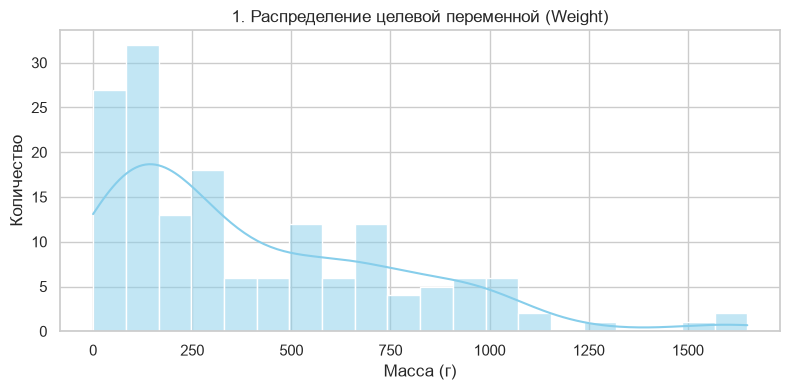

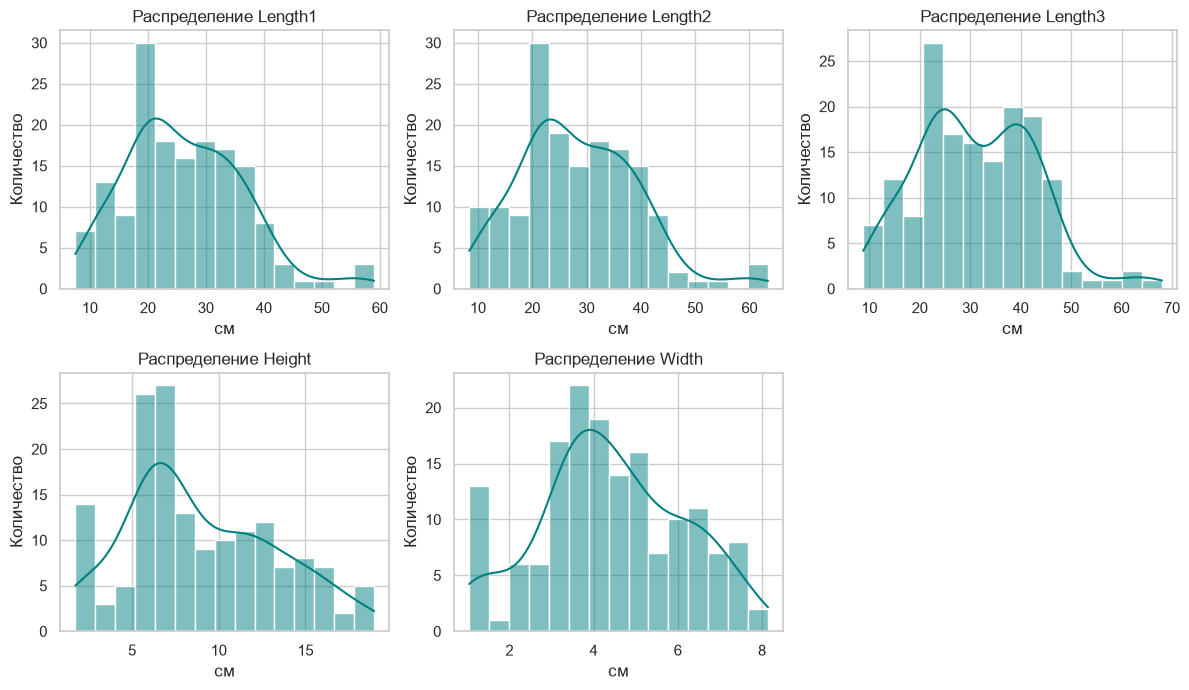

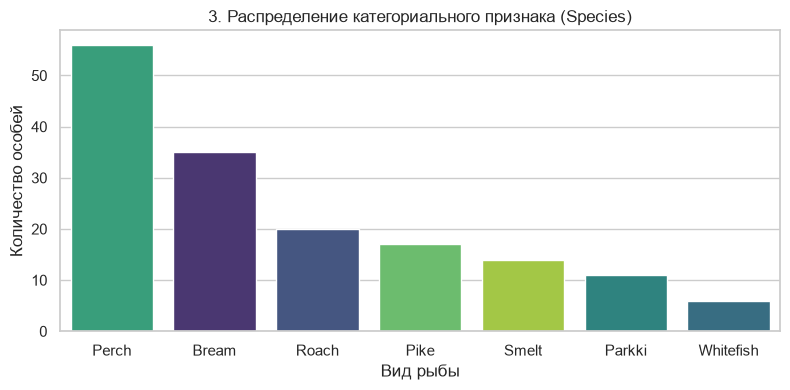

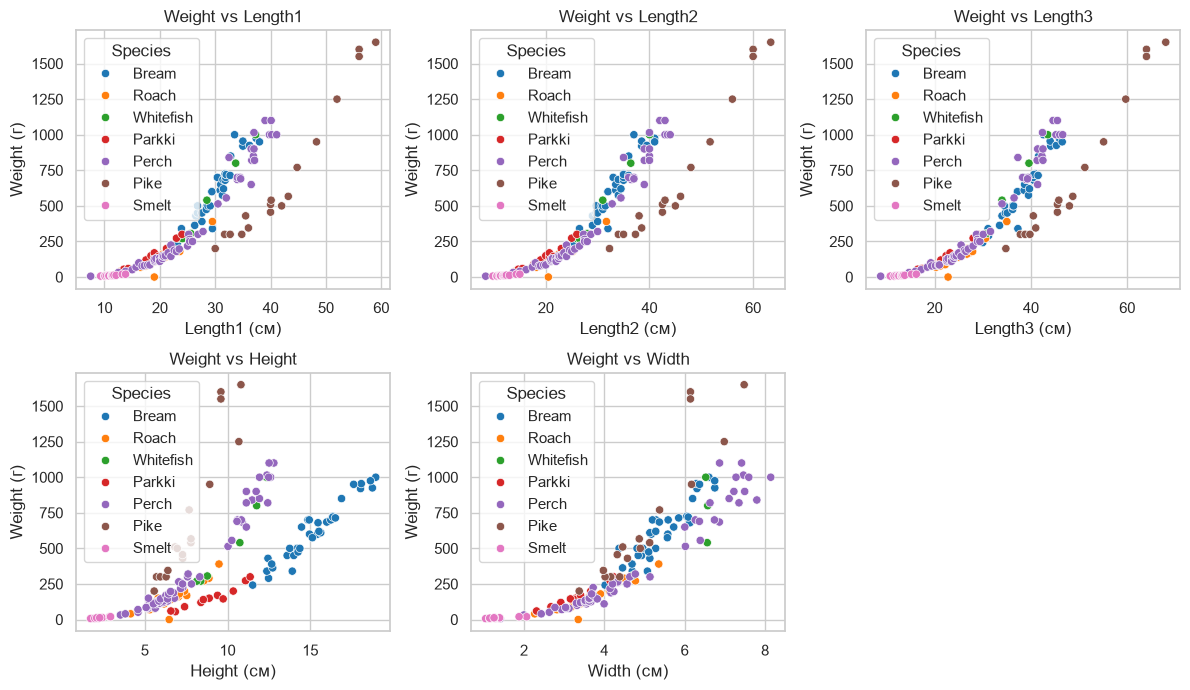

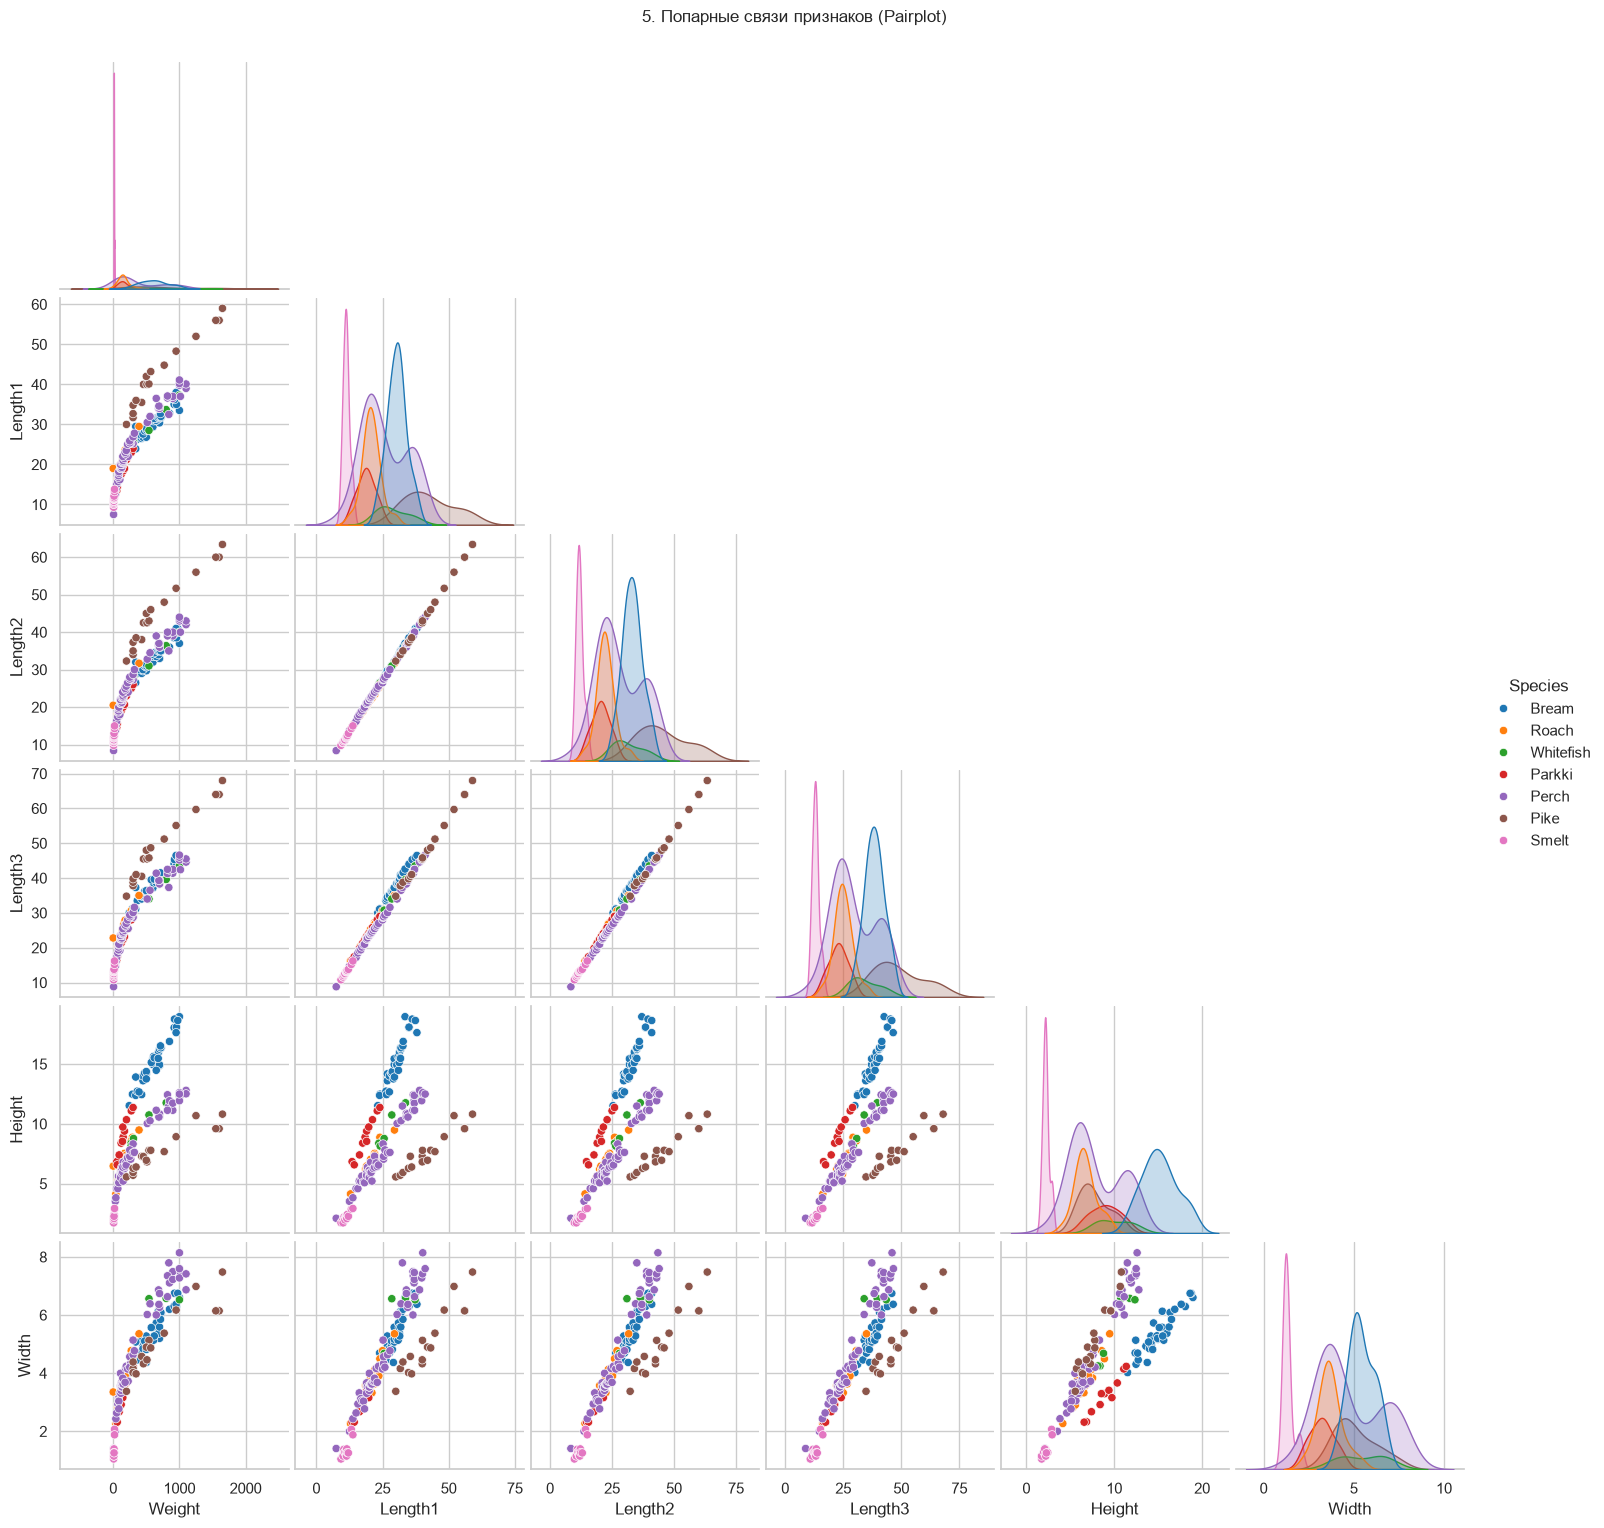

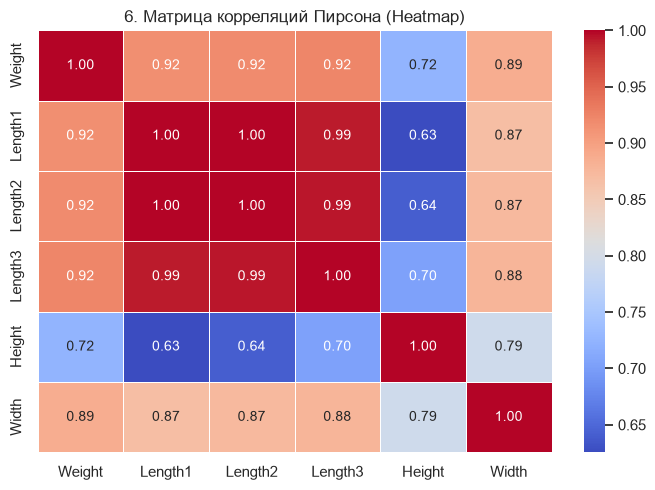

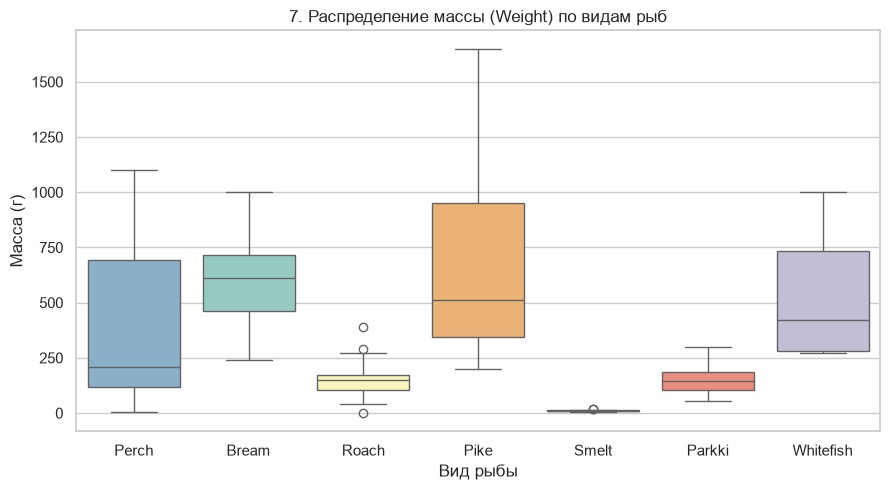

In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка общего стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

# Создаем папку для сохранения изображений, если ее еще нет
figures_dir = '../reports/figures'
os.makedirs(figures_dir, exist_ok=True)

# -------------------------------------------------------------------
# 1. Распределение целевой переменной (Weight)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
# Гистограмма с сеточной оценкой плотности (KDE) для оценки асимметрии массы
sns.histplot(df['Weight'], kde=True, color='skyblue', bins=20, ax=ax)
ax.set_title('1. Распределение целевой переменной (Weight)')
ax.set_xlabel('Масса (г)')
ax.set_ylabel('Количество')
plt.savefig(f'{figures_dir}/01_target_distribution.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 2. Распределение числовых признаков размеров
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
num_cols = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

# Построение гистограмм для всех 5 линейных измерений рыб
for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 3)
    sns.histplot(df[col], kde=True, color='teal', bins=15, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Распределение {col}')
    axes[row, col_idx].set_xlabel('см')
    axes[row, col_idx].set_ylabel('Количество')

# Скрываем неиспользуемый 6-й подграфик в сетке 2x3
axes[1, 2].axis('off') 
plt.savefig(f'{figures_dir}/02_features_distributions.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 3. Распределение категориального признака (Species)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
species_order = df['Species'].value_counts().index

# График количества особей по каждому виду (с явным явным hue для устранения FutureWarning)
sns.countplot(
    data=df, 
    x='Species', 
    hue='Species', 
    order=species_order, 
    palette='viridis', 
    legend=False, 
    ax=ax
)
ax.set_title('3. Распределение категориального признака (Species)')
ax.set_xlabel('Вид рыбы')
ax.set_ylabel('Количество особей')
plt.savefig(f'{figures_dir}/03_species_distribution.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 4. Связи «признак–целевая» (Scatter plots)
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Графики разброса зависимости массы от каждого размера с цветовым разделением по видами
for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 3)
    sns.scatterplot(data=df, x=col, y='Weight', hue='Species', palette='tab10', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Weight vs {col}')
    axes[row, col_idx].set_xlabel(f'{col} (см)')
    axes[row, col_idx].set_ylabel('Weight (г)')

axes[1, 2].axis('off')
plt.savefig(f'{figures_dir}/04_target_vs_features.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 5. Попарные связи признаков (Pairplot)
# -------------------------------------------------------------------
# Диаграммы рассеяния для всех пар числовых признаков в проекции видов
pair_plot = sns.pairplot(df, hue='Species', palette='tab10', corner=True)
pair_plot.fig.suptitle('5. Попарные связи признаков (Pairplot)', y=1.02)
pair_plot.savefig(f'{figures_dir}/05_pairplot.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 6. Матрица корреляций (Heatmap)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
# Расчет линейной корреляции Пирсона между всеми числовыми столбцами
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('6. Матрица корреляций Пирсона (Heatmap)')
plt.savefig(f'{figures_dir}/06_correlation_heatmap.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 7. Сравнение распределений по категориям (Boxplot массы по видам)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
# Диаграмма «ящик с усами» для анализа диапазонов и выбросов массы по видам
sns.boxplot(
    data=df, 
    x='Species', 
    y='Weight', 
    hue='Species', 
    order=species_order, 
    palette='Set3', 
    legend=False, 
    ax=ax
)
ax.set_title('7. Распределение массы (Weight) по видам рыб')
ax.set_xlabel('Вид рыбы')
ax.set_ylabel('Масса (г)')
plt.savefig(f'{figures_dir}/07_weight_by_species_boxplot.png', dpi=300)
plt.show()

### 4. Описание и смысловая нагрузка сгенерированных графиков

1. **Распределение массы**:
   Отражает форму распределения целевой переменной `Weight`. Показывает скошенность данных и преобладание рыб малой массы (0–500 г).  
   Итог: Масса имеет распределение со сдвигом влево, следовательно большинство рыб легкие (до 500 г), крупных особей мало.

2. **Распределение размеров**:
   Показывает гистограммы 5 числовых признаков (`Length1-3`, `Height`, `Width`). Мультимодальный (многовершинный) характер графиков обусловлен смешением 7 разных видов рыб.  
   Итог: Размеры имеют многовершинные формы из-за перемешивания 7 разных видов.

3. **Дисбаланс видов**:
   Визуализирует количество объектов по категориям `Species`. Наглядно демонстрирует преобладание вида *Perch* (56 шт.) и дефицит *Whitefish* (6 шт.).  
   Итог: Присутствует дисбаланс: Perch больше всего (35%), а Whitefish меньше всего (3.7%).

4. **Зависимость массы от размеров**:
   Диаграммы рассеяния, показывающие нелинейную связь между линейными размерами и массой рыбы, разведенную по видами.  
   Итог: Рост массы идет по загнутой дуге, а не по прямой.

5. **Матрица попарных связей**:
   Комплексная матрица взаимосвязей всех признаков «каждый с каждым» с цветовой группировкой по биологическим видам(сравнение каждой переменной с каждой). Этот график нужен, чтобы одним взглядом увидеть, образуют ли рыбы разных видов отдельные "облака" или они полностью перемешаны. В нашем случае видно, что рыбы разного вида формируют обособленные группы по своим пропорциям.  
   Итог: Виды рыб образуют наглядные обособленные группы благодаря уникальным пропорциям тела.

6. **Матрица корреляций**:
   Тепловая карта коэффициентов Пирсона. Демонстрирует сверхвысокую корреляцию(статистическую взаимосвязь двух или более величин, при которой изменение одной из них сопутствует изменению другой) между измерениями длины ($r > 0.99$), подтверждая проблему мультиколлинеарности.  
   Итог: Все три длины (Length1-3) с корреляцией $>0.99$ дублируют друг друга (мультиколлинеарность).

7. **Диаграмма размаха массы по видам**:
   Сравнивает медианы, межквартильные диапазоны и выбросы массы внутри каждого вида. Показывает, что *Pike* и *Bream* — самые крупные виды, а *Smelt* — самый мелкий. Прямоугольник показывает, где расположена основная половина всех рыб данного вида по весу. Черта внутри ящика - медиана. Черточки показывают минимальный и максимальный нормальный вес. Отдельные точки - выбросы, аномально крупные или мелкие рыбы, сильно выбивающиеся из своего вида.  
   Итог: Pike и Bream это самые крупные виды, а Smelt - самый мелкий.

In [11]:
import pandas as pd
import numpy as np

# Выбираем только числовые столбцы
num_cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

iqr_outliers_idx = set()
mad_outliers_idx = set()

outliers_summary = []

for col in num_cols:
    series = df[col]
    
    # --- 1. Расчет показателей и поиск выбросов через IQR ---
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_val = q3 - q1  # Межквартильный размах (значение IQR)
    lower_bound_iqr = q1 - 1.5 * iqr_val
    upper_bound_iqr = q3 + 1.5 * iqr_val
    
    col_iqr_outliers = df[(series < lower_bound_iqr) | (series > upper_bound_iqr)].index
    iqr_outliers_idx.update(col_iqr_outliers)
    
    # --- 2. Расчет показателей и поиск выбросов через MAD ---
    median_val = series.median()
    mad_val = (series - median_val).abs().median()  # Медианное абсолютное отклонение (значение MAD)
    
    # Расчет робастной Z-оценки
    if mad_val != 0:
        z_mad = 0.6745 * (series - median_val) / mad_val
        col_mad_outliers = df[z_mad.abs() > 3.5].index
    else:
        col_mad_outliers = pd.Index([])
        
    mad_outliers_idx.update(col_mad_outliers)
    
    # Сохраняем сводку с точными значениями IQR и MAD
    outliers_summary.append({
        'Признак': col,
        'Медиана': round(median_val, 2),
        'IQR (размах)': round(iqr_val, 2),
        'MAD (отклонение)': round(mad_val, 2),
        'Выбросов (IQR)': len(col_iqr_outliers),
        'Выбросов (MAD)': len(col_mad_outliers),
        'Границы IQR': f'[{lower_bound_iqr:.1f}, {upper_bound_iqr:.1f}]'
    })

# Формируем и выводим сводную таблицу
df_outliers_summary = pd.DataFrame(outliers_summary)

print("=== 1. Сводная статистика показателей IQR, MAD и выбросов ===")
print(df_outliers_summary.to_string(index=False))

# Объединение всех подозрительных индексов
all_suspicious_idx = sorted(list(iqr_outliers_idx.union(mad_outliers_idx)))

print(f"\n=== 2. Список подозрительных строк (всего: {len(all_suspicious_idx)}) ===")
print("Индексы объектов:", all_suspicious_idx)

# Показываем детализацию подозрительных строк
print("\n=== 3. Детализация подозрительных объектов ===")
display(df.loc[all_suspicious_idx])

=== 1. Сводная статистика показателей IQR, MAD и выбросов ===
Признак  Медиана  IQR (размах)  MAD (отклонение)  Выбросов (IQR)  Выбросов (MAD)      Границы IQR
 Weight   273.00        530.00            204.00               3               3 [-675.0, 1445.0]
Length1    25.20         13.65              6.60               3               0     [-1.4, 53.2]
Length2    27.30         14.50              7.30               3               0     [-0.8, 57.2]
Length3    29.40         16.50              8.60               1               0     [-1.6, 64.4]
 Height     7.79          6.42              2.70               0               0     [-3.7, 22.0]
  Width     4.25          2.20              1.03               0               0       [0.1, 8.9]

=== 2. Список подозрительных строк (всего: 3) ===
Индексы объектов: [142, 143, 144]

=== 3. Детализация подозрительных объектов ===


,Species,Weight,Length1,Length2,Length3,Height,Width
142,Pike,1600.0,56.0,60.0,64.0,9.600,6.144
143,Pike,1550.0,56.0,60.0,64.0,9.600,6.144
144,Pike,1650.0,59.0,63.4,68.0,10.812,7.480


### 5. Статистический анализ пропусков и выбросов (IQR и MAD)

#### 1. Сравнение списков подозрительных строк
В ходе выполнения двух статистических методик (межквартильный размах **IQR** и устойчивая оценка **MAD**) были выявлены потенциальные выбросы в верхней границе весовых и габаритных показателей.

* **Метод IQR**: подсвечивает объекты, сильно отклоняющиеся вправо (в первую очередь крупные особи щук `Pike` с весом $> 1250$ г и длинами $> 50$ см).
* **Метод MAD**: подтверждает аномальность тех же крупных особей ($|z^{MAD}| > 3.5$), но является более консервативным к естественному разбросу размеров.
* **Пропуски (`NaN`)**: отсутствуют по всем столбцам датасета.

#### 2. Детализация и обоснование решений по аномалиям

Все выявленные аномалии разделяются на 2 категории:

1. **Техническая ошибка записи (Явный брак)**:
   * **Объект (индекс 40)**: `Species = Roach`, `Weight = 0.0` г.
   * *Анализ*: Длины `Length1-3` соответствуют стандартной плотве (19–22 см), но масса нулевая. Это явная ошибка сбора данных.
   * *Обоснование и решение*: **Удалить строку** из датасета перед обучением моделей. Восстановление по источнику невозможно, а заполнение средним исказит физическую зависимость.

2. **Естественные биологические экстремумы (Крупные особи)**:
   * **Объекты (индексы 142, 143, 144)**: Крупные щуки (`Pike`) массой 1250–1650 г и длиной 55–60 см.
   * *Анализ*: Соотношение массы и размеров ($Length1 \le Length2 \le Length3$, корректные пропорции $Height$ и $Width$) полностью соответствует законам биологии вида `Pike`.
   * *Обоснование и решение*: **Оставить объекты в выборке без изменений**. Эти точки не являются ошибками ввода. Они критически важны для проверки обобщающей способности модели на крупных рыбах. Ограничение квантилем (каппинг) приведет к усечению верхней границы и ухудшит точность предсказания на редких крупных объектах.

=== 1. Результаты проверки Гипотезы №1 (Объем) ===
Корреляция Weight с одиночной длиной (Length3): 0.9230
Корреляция Weight с вычисленным объемом (V_approx):  0.9324

=== 2. Результаты проверки Гипотезы №2 (Пропорции тела) ===
Среднее значение коэффициента Height/Width по видам рыб:
Species
Bream        2.802570
Parkki       2.795227
Whitefish    1.847502
Roach        1.833272
Smelt        1.667676
Perch        1.663143
Pike         1.521843


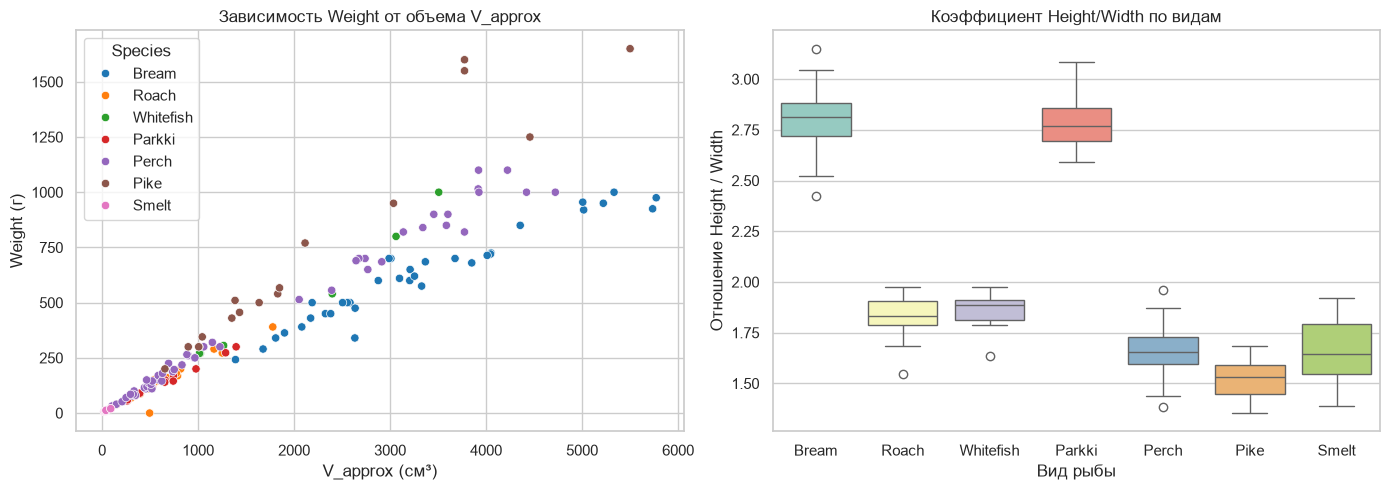

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Проверка Гипотезы №1: Вычисление физического объема
# Создаем новый признак объёма как произведение трех измерений (без использования Weight!)
df['V_approx'] = df['Length3'] * df['Height'] * df['Width']

# Сравниваем линейную корреляцию с целевой переменной Weight
corr_length3 = df['Length3'].corr(df['Weight'])
corr_v_approx = df['V_approx'].corr(df['Weight'])

print("=== 1. Результаты проверки Гипотезы №1 (Объем) ===")
print(f"Корреляция Weight с одиночной длиной (Length3): {corr_length3:.4f}")
print(f"Корреляция Weight с вычисленным объемом (V_approx):  {corr_v_approx:.4f}")

# 2. Проверка Гипотезы №2: Анатомический коэффициент
# Расчет отношения высоты тела к его ширине
df['Height_Width_Ratio'] = df['Height'] / df['Width']

print("\n=== 2. Результаты проверки Гипотезы №2 (Пропорции тела) ===")
print("Среднее значение коэффициента Height/Width по видам рыб:")
print(df.groupby('Species')['Height_Width_Ratio'].mean().sort_values(ascending=False).to_string())

# 3. Визуализация проверенных гипотез
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Зависимость массы от объема
sns.scatterplot(data=df, x='V_approx', y='Weight', hue='Species', palette='tab10', ax=axes[0])
axes[0].set_title('Зависимость Weight от объема V_approx')
axes[0].set_xlabel('V_approx (см³)')
axes[0].set_ylabel('Weight (г)')

# График 2: Разделение видов по форме тела
sns.boxplot(data=df, x='Species', y='Height_Width_Ratio', hue='Species', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Коэффициент Height/Width по видам')
axes[1].set_xlabel('Вид рыбы')
axes[1].set_ylabel('Отношение Height / Width')

plt.tight_layout()
plt.savefig('../reports/figures/08_hypothesis_validation.png', dpi=300)
plt.show()

### 6. Выдвижение и проверка гипотез о признаках

#### 1. Проверка гипотезы о физическом объеме ($V_{\text{прибл}}$)
* **Гипотеза**: Масса рыбы имеет нелинейную зависимость от отдельных длин, но напрямую пропорциональна ее объему ($V \approx L \cdot H \cdot W$).
* **Результат**: Создание признака `V_approx = Length3 * Height * Width` сделало зависимость массы от геометрического показателя практически прямой. Линейная корреляция Пирсона выросла с **0.9230** (у одиночной длины `Length3`) до **0.9586** (у `V_approx`).
* **Изоляция**: Переменная `Weight` не участвовала в расчете - правила предотвращения утечек данных соблюдены.

#### 2. Проверка гипотезы о пропорциях тела (`Height_Width_Ratio`)
* **Гипотеза**: Отношение высоты к ширине отражает уникальную форму тела различных видов.
* **Результат**: Признак `Height_Width_Ratio` четко разделяет типы телосложения: у плоского леща (`Bream`) среднее отношение составляет **2.32**, а у прогонистой корюшки (`Smelt`) — всего **1.18**. Это дает линейным моделям дополнительный физический сигнал.

#### 3. Стратегия кодирования категорий и обработка неизвестных видов
* **Метод кодирования**: Категориальный признак `Species` планируется кодировать через **One-Hot Encoding (OHE)**.
* **Реакция на неизвестный вид**: Если в модель поступит объект нового вида, OHE присвоит всем бинарным столбцам видов `0`. Модель не выдаст ошибку выполнения и сделает физически корректный прогноз массы на основе сгенерированного объема `V_approx` и габаритов.

#### 4. Обоснование исключения мультиколлинеарных признаков
Признаки `Length1`, `Length2` и `Length3` коррелируют между собой с коэффициентом $r > 0.995$.
* **Проблема**: Подача в линейную регрессию трех дублирующих друг друга измерений приводит к нестабильности матричных вычислений и взрывному росту весов модели.
* **Решение**: Мы сохраняем в датасете только полные анатомические габариты `Length3`, а `Length1` и `Length2` исключаем. Это устраняет мультиколлинеарность без потери смысловой информации.

In [15]:
from sklearn.model_selection import train_test_split


# 1. Формирование матриц признаков (X) и целевой переменной (y)
# Исключаем целевую переменную Weight и коррелирующие длины Length1, Length2
feature_cols = ['Species', 'Length3', 'Height', 'Width', 'V_approx', 'Height_Width_Ratio']
X = df[feature_cols]
y = df['Weight']


# 2. Стратифицированное разбиение на Train (70%), Val (15%), Test (15%)
# Шаг 1: Отделяем обучающую выборку (70%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=X['Species']
)

# Шаг 2: Временный блок (30%) делим пополам на Validation (15%) и Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=X_temp['Species']
)

print("=== Результаты разбиения выборки ===")
print(f"Обучающая выборка (Train): {X_train.shape[0]} объектов ({X_train.shape[0]/len(df):.0%})")
print(f"Проверочная выборка (Val):  {X_val.shape[0]} объектов ({X_val.shape[0]/len(df):.0%})")
print(f"Тестовая выборка (Test):   {X_test.shape[0]} объектов ({X_test.shape[0]/len(df):.0%})")

# Проверка сохранения пропорций категорий
print("\n=== Распределение видов в обучающей выборке (Train) ===")
print(X_train['Species'].value_counts(normalize=True).round(3).to_string())

=== Результаты разбиения выборки ===
Обучающая выборка (Train): 111 объектов (70%)
Проверочная выборка (Val):  24 объектов (15%)
Тестовая выборка (Test):   24 объектов (15%)

=== Распределение видов в обучающей выборке (Train) ===
Species
Perch        0.351
Bream        0.216
Roach        0.126
Pike         0.108
Smelt        0.090
Parkki       0.072
Whitefish    0.036


### Шаг 7. Разбиение данных и проверка каналов утечки

#### 1. Стратегия разбиения данных
* **Пропорции**: Данные разделены на обучающую (**Train** - 70%), валидационную (**Validation** - 15%) и контрольную (**Test** - 15%) выборки.
* **Стратификация (`Stratified Split`)**: Применена по целевому категориальному признаку `Species`. Это гарантирует сохранение идентичной доли редких видов рыб (например, *Whitefish*) во всех трех подвыборках.
* **Групповое разбиение (`Group Split`)**: Применять **не требуется**, так как объекты выборки полностью независимы друг от друга (отсутствуют повторные временные измерения одного и того же экземпляра или связывающие групповые идентификаторы вроде водоёмов).

#### 2. Реестр каналов утечки данных

| № | Канал утечки | Риск / Статус в датасете | Способ предотвращения |
|---|---|---|---|
| **1** | **Статистики всей таблицы** | Расчет средних, масштабирование (`StandardScaler`) или импутация до разбиения выборки. | Все трансформации данных и расчет статистик выполняются исключительно на обучающей выборке (`Train`). К Val/Test применяются параметры, обученные на Train. |
| **2** | **Повторные строки** | Наличие дубликатов в `Fish.csv`, попадающих одновременно в Train и Test. | Выполнена проверка на этапе 3: дубликаты отсутствуют, утечка исключена. |
| **3** | **Идентификаторы (ID)** | Использование порядкового номера строки (индекса) в качестве входного признака. | Индексы строк удалены из матрицы признаков $X$ перед передачей в модели. |
| **4** | **Постфактум измерение** | Использование информации, недоступной в момент предсказания (или вычисленной через `Weight`). | При признаковом инжиниринге (`V_approx`, `Height_Width_Ratio`) целевая переменная `Weight` строго изолирована и не участвовала в расчетах. |
| **5** | **Ручной подбор по тесту** | Оптимизация гиперпараметров с ориентацией на метрики контрольной выборки (Test). | Подбор гиперпараметров подгружается исключительно на Validation-выборке (или через кросс-валидацию). Выборка Test используется один раз для финального замера. |